In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import episcanpy as epi
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import glob
import os

from pathlib import Path
from scipy import io
from helps import *

# Raw CM

## Peak

In [2]:
fr_file="Datasets/HSPC/RawFiles/GSM6403411_3423-MV-2_atac_fragments.tsv.gz"
metadata=sc.read_h5ad("Datasets/HSPC/RawFiles/3423-MV-2_adata_postpro.h5ad").obs
metadata=pd.DataFrame(metadata["leiden"])
metadata.rename({"leiden" : "CellType"}, axis=1, inplace=True)
features_space="Peak"
features_file="Datasets/HSPC/RawFiles/HSPC_PeakCalling/HSPC_peaks.narrowPeak"
adata=create_count_matrix(fragments_file=fr_file, valid_bcs=list(set(metadata.index)), features_space=features_space,
                          features_file=features_file, metadata=metadata)

In [3]:
epi.pp.nucleosome_signal(adata,fr_file, n=10000)
epi.pp.tss_enrichment(adata, gtf="../AnnotRef/hs/hg38/gencode.v44.annotation.gtf.gz", source="HAVANA",
                      fragments=fr_file, n=5000, score="avg_score_of_center_region", distance_to_tss=1000, bp_per_flank=100)
Path("Datasets/HSPC/CM").mkdir(parents=True, exist_ok=True)
adata.write("Datasets/HSPC/CM/HSPC_Peak_Raw.h5ad", compression="gzip")

## GEX

In [4]:
adata=sc.read_10x_mtx("Datasets/HSPC/RawFiles/gexmatrix", prefix="GSE209878_3423-MV-2_")
metadata=sc.read_h5ad("Datasets/HSPC/RawFiles/3423-MV-2_adata_postpro.h5ad").obs
metadata=pd.DataFrame(metadata["leiden"])
metadata.rename({"leiden" : "CellType"}, axis=1, inplace=True)

In [5]:
adata=adata[intersection([adata.obs.index, metadata.index])]
adata.obs=metadata.loc[adata.obs.index]
sc.pp.scrublet(adata)

In [6]:
adata.var_names_make_unique()

In [7]:
adata.write("Datasets/HSPC/CM/HSPC_GEX_Raw.h5ad", compression="gzip")

## mRNA

In [8]:
adata=sc.read_h5ad("Datasets/HSPC/CM/HSPC_GEX_Raw.h5ad")
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/hs/hg38/gencode.v44.annotation.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="HAVANA")]

gene_names=[attr.replace("gene_name", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_name")]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T

mRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="protein_coding"]["GeneName"]])]
mRNA.write("Datasets/HSPC/CM/HSPC_mRNA_Raw.h5ad", compression="gzip")

In [10]:
mRNA

View of AnnData object with n_obs × n_vars = 11605 × 18782
    obs: 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types'
    uns: 'scrublet'

## lncRNA

In [9]:
adata=sc.read_h5ad("Datasets/HSPC/CM/HSPC_GEX_Raw.h5ad")
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/hs/hg38/gencode.v44.annotation.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="HAVANA")]

gene_names=[attr.replace("gene_name", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_name")]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T

lncRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="lncRNA"]["GeneName"]])]
lncRNA.write("Datasets/HSPC/CM/HSPC_lncRNA_Raw.h5ad", compression="gzip")

In [11]:
lncRNA

View of AnnData object with n_obs × n_vars = 11605 × 3988
    obs: 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types'
    uns: 'scrublet'

# Processing

## Peak

In [6]:
adata=sc.read_h5ad("Datasets/HSPC/CM/HSPC_Peak_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 11605 × 226005
    obs: 'CellType', 'nucleosome_signal', 'tss_enrichment_score'
    var: 'chr', 'start', 'stop'
    uns: 'fragment_lengths', 'tss_enrichment'
    layers: 'raw'

In [17]:
epi.pp.qc_stats(adata, verbose=False)

In [18]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

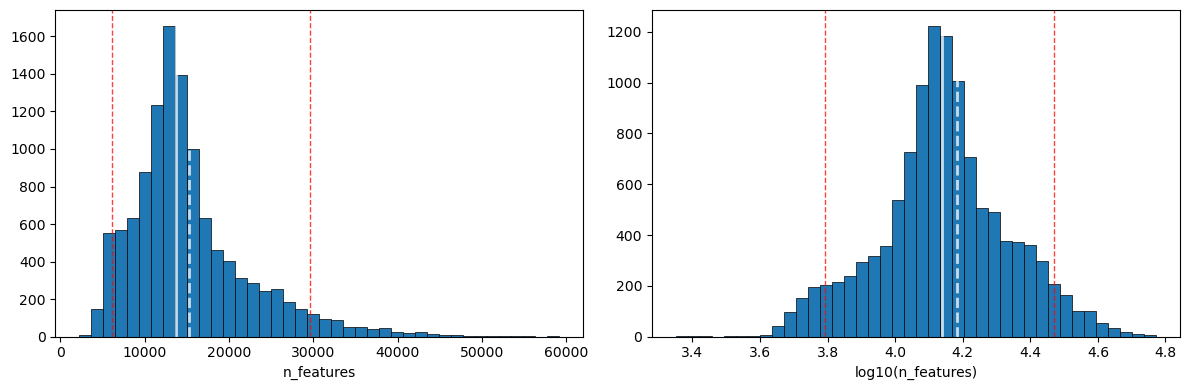

Max:	59143
Median:	13745.0
Mean:	15292.866092201637
Min:	2248


In [19]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

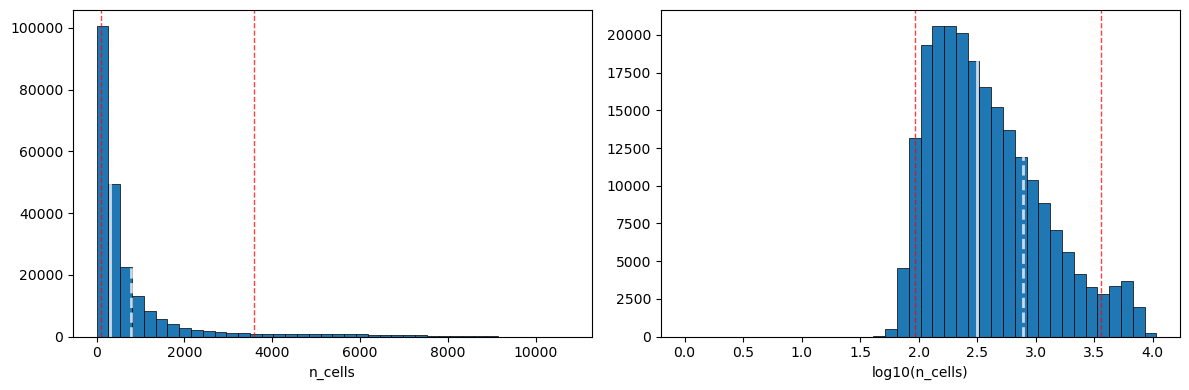

Max:	10739
Median:	313.0
Mean:	785.2645339704874
Min:	0


In [20]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

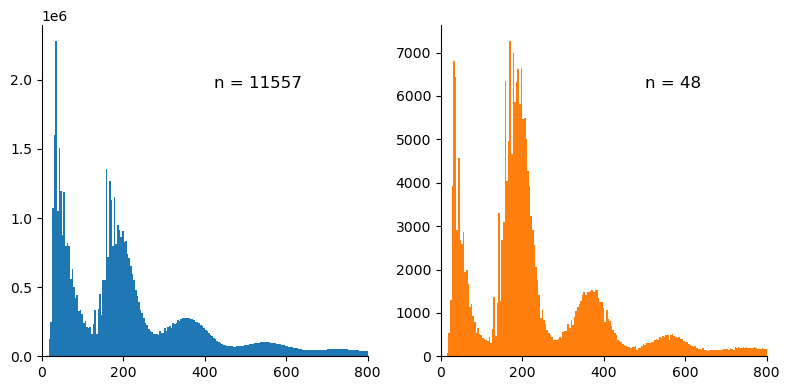

In [ ]:
max_nucleosome_signal=2
epi.pl.fragment_length(adata, n=5000, threshold=max_nucleosome_signal, show_n=True)

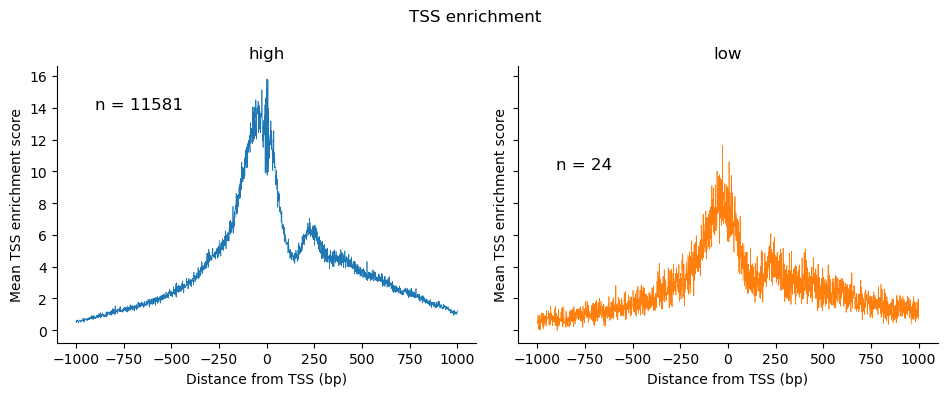

In [18]:
min_tss_enrichment = 4
adata.obs["tss"] = ["high" if val > min_tss_enrichment else "low" for val in adata.obs.tss_enrichment_score]

epi.pl.tss_enrichment(adata, group_by="tss", show_n=True)

In [21]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata=adata[adata.obs.nucleosome_signal < max_nucleosome_signal]
adata=adata[adata.obs.tss_enrichment_score > min_tss_enrichment]
adata

View of AnnData object with n_obs × n_vars = 10389 × 203998
    obs: 'CellType', 'nucleosome_signal', 'tss_enrichment_score', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'fragment_lengths', 'tss_enrichment'

In [22]:
epi.pp.normalize_total(adata)

In [26]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.9)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 10389 × 20400
    obs: 'CellType', 'nucleosome_signal', 'tss_enrichment_score', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'fragment_lengths', 'tss_enrichment', 'hvg'

In [27]:
adata.write("Datasets/HSPC/CM/HSPC_Peak_Def.h5ad", compression="gzip")

## GEX

In [7]:
adata=sc.read_h5ad("Datasets/HSPC/CM/HSPC_GEX_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 11605 × 36601
    obs: 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types'
    uns: 'scrublet'
    layers: 'raw'

In [40]:
epi.pp.qc_stats(adata, verbose=True)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [41]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

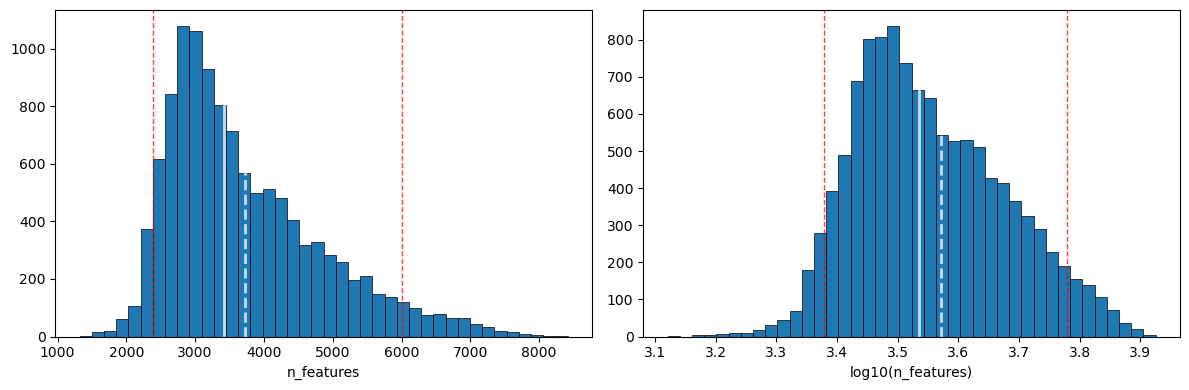

Max:	8413
Median:	3423.0
Mean:	3723.510900473934
Min:	1321


In [42]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

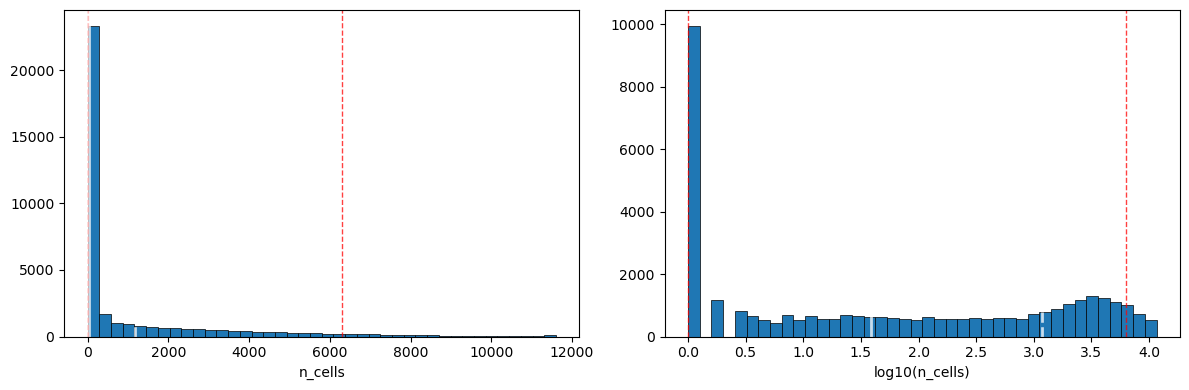

Max:	11605
Median:	39.0
Mean:	1180.6055572252124
Min:	0


In [43]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

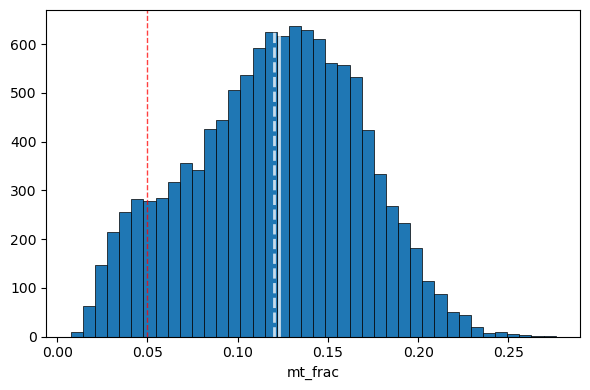

Max:	0.2762202322483063
Median:	0.12303980439901352
Mean:	0.12028809636831284
Min:	0.007423117756843567


In [44]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [45]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.15]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 6244 × 26883
    obs: 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'scrublet'

In [46]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [47]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.8)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]

In [48]:
adata

View of AnnData object with n_obs × n_vars = 6244 × 5377
    obs: 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'log1p', 'hvg'

In [49]:
adata.write("Datasets/HSPC/CM/HSPC_GEX_Def.h5ad", compression="gzip")

## mRNA

In [8]:
adata=sc.read_h5ad("Datasets/HSPC/CM/HSPC_mRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 11605 × 18782
    obs: 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types'
    uns: 'scrublet'
    layers: 'raw'

In [51]:
epi.pp.qc_stats(adata, verbose=True)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [52]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

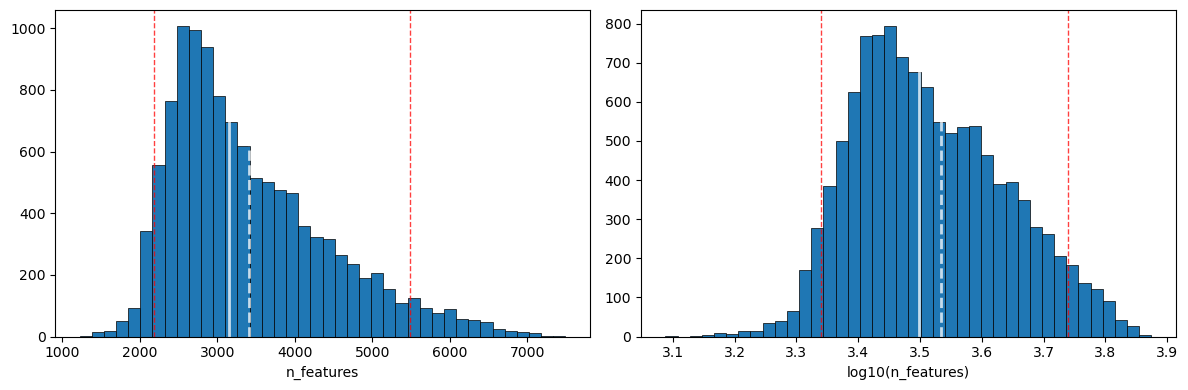

Max:	7490
Median:	3155.0
Mean:	3415.810771219302
Min:	1225


In [53]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

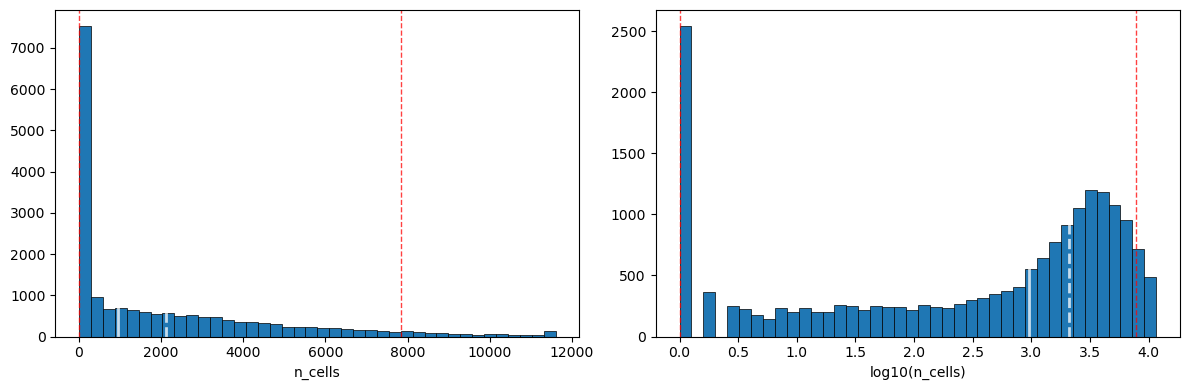

Max:	11605
Median:	947.0
Mean:	2110.557129166223
Min:	0


In [54]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

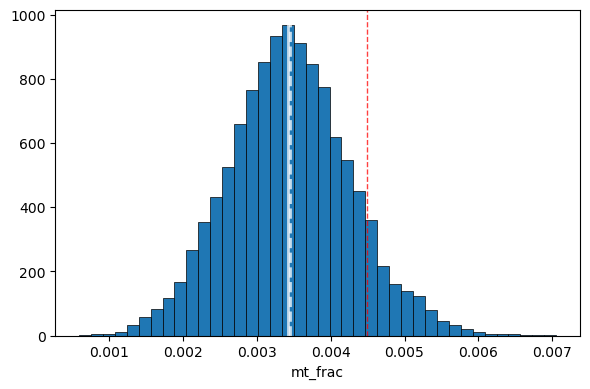

Max:	0.007055893540382385
Median:	0.0034260114189237356
Mean:	0.003440865548327565
Min:	0.0005877166986465454


In [55]:
max_mt = np.quantile(adata.obs["mt_frac"].dropna(), 0.9)
epi.pl.histogram(adata, "mt_frac", max_threshold=max_mt, show_log=False)

In [56]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 8892 × 15866
    obs: 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'scrublet'

In [57]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [58]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')

In [59]:
min_var = np.quantile(adata.var.variances_norm, 0.65)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 8892 × 5553
    obs: 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'log1p', 'hvg'

In [60]:
adata.write("Datasets/HSPC/CM/HSPC_mRNA_Def.h5ad", compression="gzip")

## lncRNA

In [9]:
adata=sc.read_h5ad("Datasets/HSPC/CM/HSPC_lncRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 11605 × 3988
    obs: 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types'
    uns: 'scrublet'
    layers: 'raw'

In [62]:
epi.pp.qc_stats(adata, verbose=True)

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [63]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

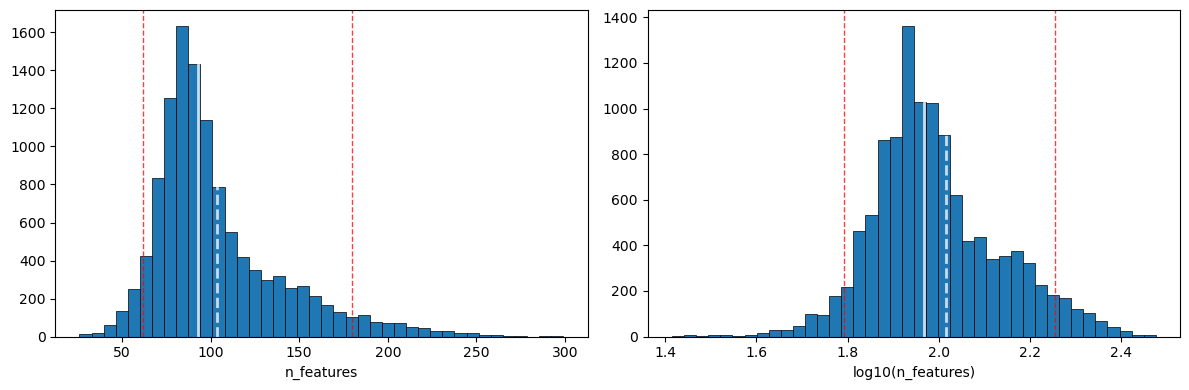

Max:	299
Median:	93.0
Mean:	103.5005601034037
Min:	26


In [64]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

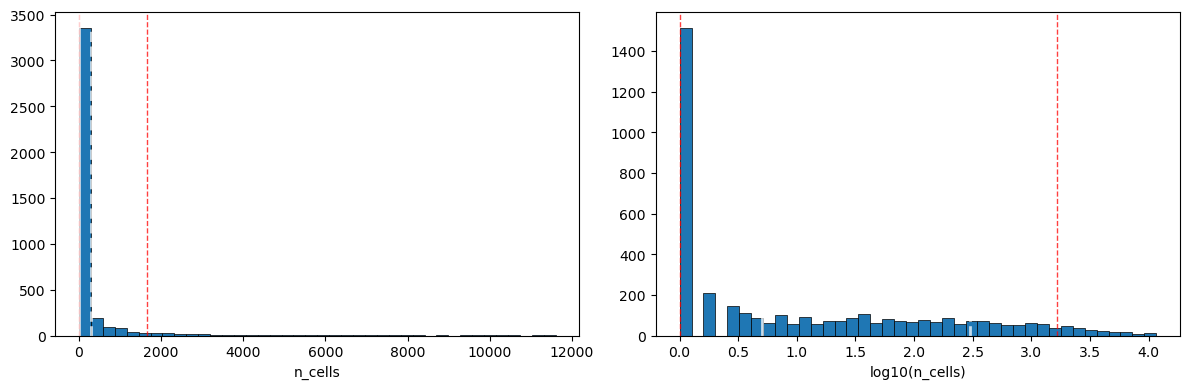

Max:	11602
Median:	5.0
Mean:	301.18455366098294
Min:	0


In [65]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [66]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 8949 × 2638
    obs: 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'scrublet'

In [67]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [68]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')

In [70]:
min_var = np.quantile(adata.var.variances_norm, 0.15)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 8949 × 2242
    obs: 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'gene_ids', 'feature_types', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'log1p', 'hvg'

In [71]:
adata.write("Datasets/HSPC/CM/HSPC_lncRNA_Def.h5ad", compression="gzip")

## Muon objects

In [2]:
for fs in ["Peak","mRNA","lncRNA","GEX"]:
    print(fs)
    adata_raw=sc.read_h5ad(f"Datasets/HSPC/CM/HSPC_{fs}_Raw.h5ad")
    adata_raw.X=scipy.sparse.csr_matrix(adata_raw.X.copy())
    adata_raw.layers["raw"]=scipy.sparse.csr_matrix(adata_raw.X.copy())
    adata_raw.write(f"Datasets/HSPC/CM/HSPC_{fs}_Raw.h5ad", compression="gzip")

    adata=sc.read_h5ad(f"Datasets/HSPC/CM/HSPC_{fs}_Def.h5ad")
    adata_raw=adata_raw[adata.obs.index, adata.var.index]
    adata.layers["raw"]=scipy.sparse.csr_matrix(adata_raw.X.copy())
    adata.write(f"Datasets/HSPC/CM/HSPC_{fs}_Def.h5ad", compression="gzip")

Peak
mRNA
lncRNA
GEX


In [4]:
import muon as mu
peak=sc.read_h5ad(f"Datasets/HSPC/CM/HSPC_Peak_Def.h5ad")
gex=sc.read_h5ad(f"Datasets/HSPC/CM/HSPC_GEX_Def.h5ad")
mrna=sc.read_h5ad(f"Datasets/HSPC/CM/HSPC_mRNA_Def.h5ad")
lncrna=sc.read_h5ad(f"Datasets/HSPC/CM/HSPC_lncRNA_Def.h5ad")

#Peak + GEX
print("Peak + GEX")
inter=intersection([peak.obs.index, gex.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "GEX" : gex[inter]})
mudata.write_h5mu(f"Datasets/HSPC/CM/HSPC_Peak_GEX_Def.h5mu", compression="gzip")

#Peak + mRNA
print("Peak + mRNA")
inter=intersection([peak.obs.index, mrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "mRNA" : mrna[inter]})
mudata.write_h5mu(f"Datasets/HSPC/CM/HSPC_Peak_mRNA_Def.h5mu", compression="gzip")

#Peak + lncRNA
print("Peak + lncRNA")
inter=intersection([peak.obs.index, lncrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/HSPC/CM/HSPC_Peak_lncRNA_Def.h5mu", compression="gzip")

#mRNA + lncRNA
print("mRNA + lncRNA")
inter=intersection([mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/HSPC/CM/HSPC_mRNA_lncRNA_Def.h5mu", compression="gzip")

#Peak + mRNA + lncRNA
print("Peak + mRNA + lncRNA")
inter=intersection([peak.obs.index, mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/HSPC/CM/HSPC_Peak_mRNA_lncRNA_Def.h5mu", compression="gzip")

Peak + GEX
Peak + mRNA
Peak + lncRNA
mRNA + lncRNA
Peak + mRNA + lncRNA


# CTA

In [2]:
df=sc.read_h5ad("Datasets/HSPC/CM/HSPC_GEX_Raw.h5ad").obs
df.head()

,CellType,doublet_score,predicted_doublet
CAGGGTGAGCAGGTTT-1,Prog DC,0.122558,True
GCGCTAGGTAGGATTT-1,HSC,0.207232,True
ACGACTTAGGCCCAGT-1,HSC,0.008978,False
CTCATGCTCTTAGTCT-1,LMPP,0.037606,False
ACTCCTCAGGAACGCG-1,MPP,0.042544,False


In [3]:
df[["CellType"]].to_csv("Datasets/HSPC/HSPC_Metadata.tsv.gz", sep="\t", compression="gzip")